# Group Equivariant CNN for Tetris Piece Classification

**6.7970/8.750 Symmetry and its Application to Machine Learning**

We build a group-equivariant convolutional neural network that classifies 2D tetris pieces. The network uses **group convolution** over $C_4$ or $D_4$ to guarantee equivariance by construction.

**The key demo:** we train on **one centered image per class** and the model automatically generalizes to **all** rotations and positions — no data augmentation needed!

We also show how the $A_2$ (pseudoscalar) irrep of $D_4$ can distinguish L from J and S from Z — chiral pairs related by reflection.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atomicarchitects/symm4ml-colabs/blob/main/group_conv_tetris.ipynb)

## Setup

In [ ]:
%%capture
!pip install pymatgen
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import HTML

from symm4ml import groups, rep, vib_modes, grids, plot
from symm4ml.group_conv import (
    apply_group_element_2D,
    orbit_2D,
    image2D_permutation_representation,
    image2D_group_convolution_filter_bank,
    # image2D_group_convolution,
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def image2D_group_convolution(perm_rep, reg_rep, input, filter):
    """Performs group convolution of inputs and filters over the regular representation
    Input:
        perm_rep: torch.Tensor of shape [|G|, kh*kw, kh*kw]
        reg_rep: torch.Tensor of shape [|G|, |G|, |G|] of the left regular representation
        input: torch.Tensor of shape [batch, channel_in, reg_rep_in, height, width]
        filter: torch.Tensor of shape [channel_out, channel_in, reg_rep_filter, kernel_height, kernel_width]
    Output:
        output: torch.Tensor of shape [batch, channel_out, reg_rep_out, height, width]
    """
    z, c, i, h, w = input.shape
    d, c, j, kh, kw = filter.shape
    k = perm_rep.shape[0]
    filter_bank = image2D_group_convolution_filter_bank(perm_rep, filter)
    filter_bank_contract = torch.einsum('kij,kdcjhw->dkcihw', reg_rep, filter_bank)
    conv = F.conv2d(input.reshape(z, c*i, h, w), filter_bank_contract.reshape(d*k, c*i, kh, kw), padding=2)
    return conv.reshape(z, d, k, conv.shape[2], conv.shape[3])

---
## Build the symmetry groups

$C_4$: the 4 rotations of a square (0°, 90°, 180°, 270°).

$D_4$: the 8 symmetries of a square (4 rotations + 4 reflections).

In [3]:
# C4: generated by 90-degree rotation
rot90 = np.array([[np.cos(np.pi/2), -np.sin(np.pi/2)],
                  [np.sin(np.pi/2),  np.cos(np.pi/2)]])

C4 = groups.generate_group(rot90.reshape(1, 2, 2))
C4 = C4[[3, 1, 0, 2]]  # reorder so E is first
C4_torch = torch.tensor(C4, dtype=torch.float32)
C4_table = groups.make_multiplication_table(C4)
C4_reg_rep = torch.tensor(rep.regular_representation(C4_table), dtype=torch.float32)
C4_perm_rep_3x3 = image2D_permutation_representation(C4_torch, [3, 3])

# D4: generated by 90-degree rotation + mirror
mirror_x = np.array([[-1., 0.], [0., 1.]])
D4 = groups.generate_group(np.stack([mirror_x, rot90]))
D4 = np.array(D4[::-1])  # reorder so E is first
D4_torch = torch.tensor(D4, dtype=torch.float32)
D4_table = groups.make_multiplication_table(D4)
D4_reg_rep = torch.tensor(rep.regular_representation(D4_table), dtype=torch.float32)
D4_perm_rep_3x3 = image2D_permutation_representation(D4_torch, [3, 3])

print(f"C4: {len(C4)} elements (rotations only)")
print(f"D4: {len(D4)} elements (rotations + reflections)")

C4: 4 elements (rotations only)
D4: 8 elements (rotations + reflections)


---
## Define the 7 tetromino pieces

Each piece is defined as 4 cell coordinates `(row, col)` relative to the piece center.

In [4]:
PIECES = {
    'I': np.array([[-2, 0], [-1, 0], [0, 0], [1, 0]]),
    'O': np.array([[0, 0], [0, 1], [1, 0], [1, 1]]),
    'T': np.array([[0, -1], [0, 0], [0, 1], [1, 0]]),
    'S': np.array([[0, 0], [0, 1], [1, -1], [1, 0]]),
    'Z': np.array([[0, -1], [0, 0], [1, 0], [1, 1]]),
    'L': np.array([[-1, 0], [0, 0], [1, 0], [1, 1]]),
    'J': np.array([[-1, 0], [0, 0], [1, 0], [1, -1]]),
}

PIECE_NAMES = list(PIECES.keys())
GRID_SIZE = 9
CENTER = GRID_SIZE // 2  # = 4
MARGIN = 2  # keep pieces this far from grid boundary (avoids conv padding artifacts)

In [5]:
def place_piece(coords, grid_size=9, translation=None, margin=0):
    """Place piece on a grid. If translation is None, choose randomly."""
    min_r, max_r = coords[:, 0].min(), coords[:, 0].max()
    min_c, max_c = coords[:, 1].min(), coords[:, 1].max()
    if translation is None:
        tr = np.random.randint(-min_r + margin, grid_size - max_r - margin)
        tc = np.random.randint(-min_c + margin, grid_size - max_c - margin)
    else:
        tr, tc = translation
    img = np.zeros((grid_size, grid_size))
    for r, c in coords:
        img[r + tr, c + tc] = 1.0
    return img

### Piece orbits under $C_4$ vs $D_4$

Under $C_4$ rotations, L and J are **distinct** (no rotation maps one to the other). Same for S and Z.

Under $D_4$, reflections map L$\leftrightarrow$J and S$\leftrightarrow$Z, making them **equivalent**.

In [6]:
print("Distinct orientations per piece:")
print(f"{'Piece':>5}  C4  D4")
print(f"{'─'*5:>5}  ──  ──")
for name, coords in PIECES.items():
    n_c4 = len(orbit_2D(coords, C4))
    n_d4 = len(orbit_2D(coords, D4))
    print(f"{name:>5}   {n_c4}   {n_d4}")

Distinct orientations per piece:
Piece  C4  D4
─────  ──  ──
    I   2   2
    O   1   1
    T   4   4
    S   2   4
    Z   2   4
    L   4   8
    J   4   8


---
## Orbit viewer

In [7]:
HTML(plot.piece_orbit_viewer(
    PIECES,
    groups={'C₄': C4, 'D₄': D4},
    width=800,
))

---
## Training data: one centered image per class

The entire training set is just **one image per class** — each piece in its canonical orientation, centered on the grid. The equivariant architecture handles generalization to all orientations and positions.

The test set uses random rotations and random positions.

In [8]:
# Class labels
C4_CLASSES = {name: i for i, name in enumerate(PIECE_NAMES)}  # 7 classes
D4_CLASSES = {'I': 0, 'O': 1, 'T': 2, 'S': 3, 'Z': 3, 'L': 4, 'J': 4}  # 5 classes
C4_CLASS_NAMES = PIECE_NAMES
D4_CLASS_NAMES = ['I', 'O', 'T', 'S/Z', 'L/J']

In [9]:
def make_training_set(class_map, piece_names_to_use=None):
    """One centered image per class."""
    if piece_names_to_use is None:
        piece_names_to_use = list({name: class_map[name] for name in PIECE_NAMES
                                   if name in class_map}.keys())
        # Keep only one representative per class
        seen_classes = set()
        unique_pieces = []
        for name in piece_names_to_use:
            if class_map[name] not in seen_classes:
                seen_classes.add(class_map[name])
                unique_pieces.append(name)
        piece_names_to_use = unique_pieces

    imgs = [place_piece(PIECES[name], GRID_SIZE, translation=(CENTER, CENTER))
            for name in piece_names_to_use]
    labels = [class_map[name] for name in piece_names_to_use]
    return (torch.tensor(np.array(imgs), dtype=torch.float32).unsqueeze(1),
            torch.tensor(labels, dtype=torch.long),
            piece_names_to_use)


def make_test_set(class_map, group_matrices, n_per_piece=100):
    """Random orientations and random positions (with margin from boundary)."""
    imgs, labels = [], []
    for name, coords in PIECES.items():
        for _ in range(n_per_piece):
            g_idx = np.random.randint(len(group_matrices))
            rotated = apply_group_element_2D(coords, group_matrices[g_idx])
            imgs.append(place_piece(rotated, GRID_SIZE, margin=MARGIN))
            labels.append(class_map[name])
    return (torch.tensor(np.array(imgs), dtype=torch.float32).unsqueeze(1),
            torch.tensor(labels, dtype=torch.long))

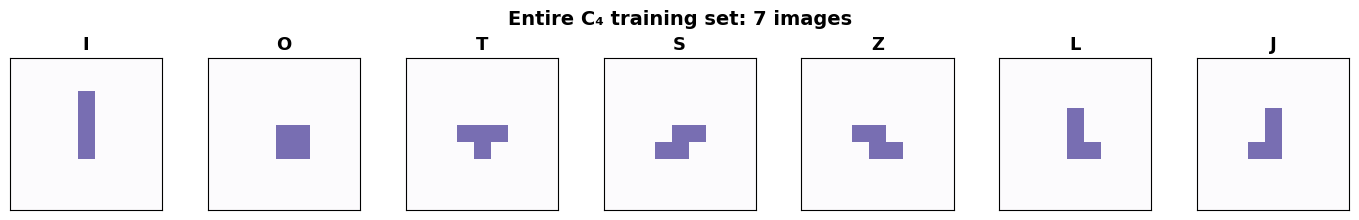

In [10]:
# Visualize the training set: just 7 centered images!
c4_train_imgs, c4_train_labels, c4_train_names = make_training_set(C4_CLASSES)
fig, axes = plt.subplots(1, 7, figsize=(14, 2.2))
for i in range(7):
    axes[i].imshow(c4_train_imgs[i, 0], cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
    axes[i].set_title(c4_train_names[i], fontsize=13, fontweight='bold')
    axes[i].set_xticks([]); axes[i].set_yticks([])
fig.suptitle('Entire C₄ training set: 7 images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Equivariant network architecture

Three stages:

1. **Lifting convolution**: scalar image → feature map over the group. For each $g \in G$, rotate the filter by $g$ and convolve.

2. **Group convolution**: group feature map → group feature map, using `image2D_group_convolution`.

3. **Invariant pooling**: average over spatial and group dims → classify.

In [11]:
def lifting_convolution(perm_rep, x, filter_weights):
    """Lift a scalar image to a feature map over the group.
    
    Input:
        perm_rep: [|G|, kh*kw, kh*kw] permutation rep on pixel grid
        x: [batch, c_in, H, W] input images
        filter_weights: [c_out, c_in, kh, kw] learnable filters
    Output:
        [batch, c_out, |G|, H, W] feature map over the group
    """
    z, c, h, w = x.shape
    d, c_f, kh, kw = filter_weights.shape
    k = perm_rep.shape[0]
    
    # Create rotated filter bank
    f_expanded = filter_weights.unsqueeze(2)  # [d, c, 1, kh, kw]
    fb = image2D_group_convolution_filter_bank(perm_rep, f_expanded)  # [|G|, d, c, 1, kh, kw]
    fb = fb[:, :, :, 0, :, :]  # [|G|, d, c, kh, kw]
    
    # Batch conv2d with all rotated filters at once
    fb_flat = fb.reshape(k * d, c_f, kh, kw)
    # out = F.conv2d(x, fb_flat, padding=kh // 2)
    out = F.conv2d(x, fb_flat, padding=2)
    return out.reshape(z, k, d, out.shape[2], out.shape[3]).permute(0, 2, 1, 3, 4)  # [batch, d, |G|, H, W]

In [12]:
class GroupEquivariantCNN(torch.nn.Module):
    """Group-equivariant CNN: lifting conv -> group conv -> pool -> classify."""
    
    def __init__(self, group='C4', num_classes=7, c1=16, c2=32):
        super().__init__()
        if group == 'C4':
            self.register_buffer('perm_rep', C4_perm_rep_3x3)
            self.register_buffer('reg_rep', C4_reg_rep)
            self.group_order = 4
        else:
            self.register_buffer('perm_rep', D4_perm_rep_3x3)
            self.register_buffer('reg_rep', D4_reg_rep)
            self.group_order = 8
        
        self.lift_w = torch.nn.Parameter(torch.randn(c1, 1, 3, 3) * 0.3)
        self.conv_w = torch.nn.Parameter(torch.randn(c2, c1, self.group_order, 3, 3) * 0.1)
        self.fc = torch.nn.Linear(c2, num_classes)
    
    def forward(self, x):
        x = lifting_convolution(self.perm_rep, x, self.lift_w)
        x = torch.relu(x)
        x = image2D_group_convolution(self.perm_rep, self.reg_rep, x, self.conv_w)
        x = torch.relu(x)
        x = x.mean(dim=(-2, -1))    # pool spatial  -> [batch, c2, |G|]
        x = x.mean(dim=-1)          # pool group    -> [batch, c2]  (A₁ invariant)
        return self.fc(x)

---
## Train $C_4$ model: 7 images → 100% on all rotations and positions

In [13]:
def train_model(model, train_imgs, train_labels, test_imgs, test_labels,
                epochs=500, lr=1e-3):
    """Train and return loss/accuracy history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    history = {'loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        logits = model(train_imgs)  # full batch (tiny!)
        loss = criterion(logits, train_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            train_acc = (model(train_imgs).argmax(1) == train_labels).float().mean().item()
            test_acc = (model(test_imgs).argmax(1) == test_labels).float().mean().item()
        history['loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:3d}: loss={loss.item():.4f}  "
                  f"train_acc={train_acc:.3f}  test_acc={test_acc:.3f}")
    return history


def plot_history(history, title, n_train=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(history['loss']); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training loss')
    train_label = f'Train ({n_train} centered imgs)' if n_train else 'Train'
    ax2.plot(history['train_acc'], label=train_label)
    ax2.plot(history['test_acc'], label='Test (random rot + pos)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.set_ylim(0, 1.05)
    ax2.set_title('Accuracy')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [14]:
np.random.seed(42)
c4_test_imgs, c4_test_labels = make_test_set(C4_CLASSES, C4, n_per_piece=100)

print(f"Training: {len(c4_train_labels)} images (one per class, centered)")
print(f"Test:     {len(c4_test_labels)} images (random C4 rotations + random positions)")

Training: 7 images (one per class, centered)
Test:     700 images (random C4 rotations + random positions)


Epoch 100: loss=1.7487  train_acc=0.714  test_acc=0.714
Epoch 200: loss=1.0963  train_acc=1.000  test_acc=1.000
Epoch 300: loss=0.5621  train_acc=1.000  test_acc=1.000
Epoch 400: loss=0.2728  train_acc=1.000  test_acc=1.000
Epoch 500: loss=0.1197  train_acc=1.000  test_acc=1.000


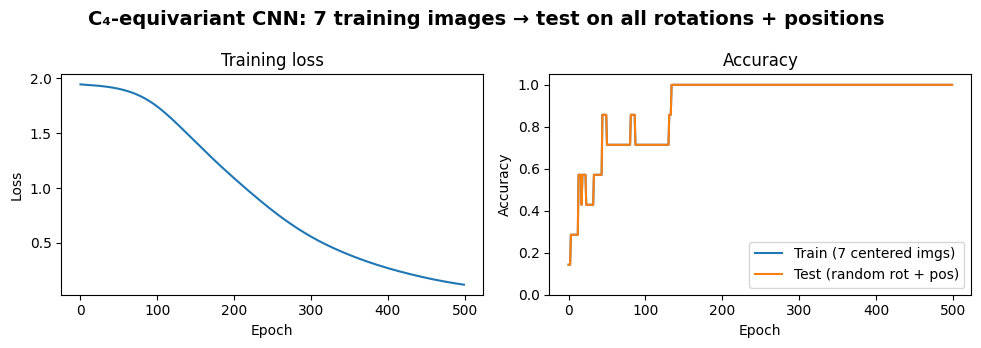

In [15]:
torch.manual_seed(0)
c4_model = GroupEquivariantCNN(group='C4', num_classes=7)
c4_history = train_model(c4_model, c4_train_imgs, c4_train_labels,
                         c4_test_imgs, c4_test_labels, epochs=500)
plot_history(c4_history, 'C₄-equivariant CNN: 7 training images → test on all rotations + positions',
             n_train=len(c4_train_labels))

In [16]:
# Visualize learned filter banks for first 4 lifting filters
fb_c4 = image2D_group_convolution_filter_bank(C4_perm_rep_3x3, c4_model.lift_w.unsqueeze(2).detach())
for i in range(4):
    display(HTML(plot.filter_bank(
        fb_c4[:, i, 0, 0].numpy(),
        rep_2D=C4,
        labels=[f'g{j}' for j in range(len(C4))],
        show_values=False,
        cmap='PuOr',
    )))

The test accuracy (on randomly rotated and translated pieces) reaches 100% — even though the model only saw **7 centered images** during training. This is the power of equivariance by construction.

---
## Verify equivariance: identical outputs for all orientations

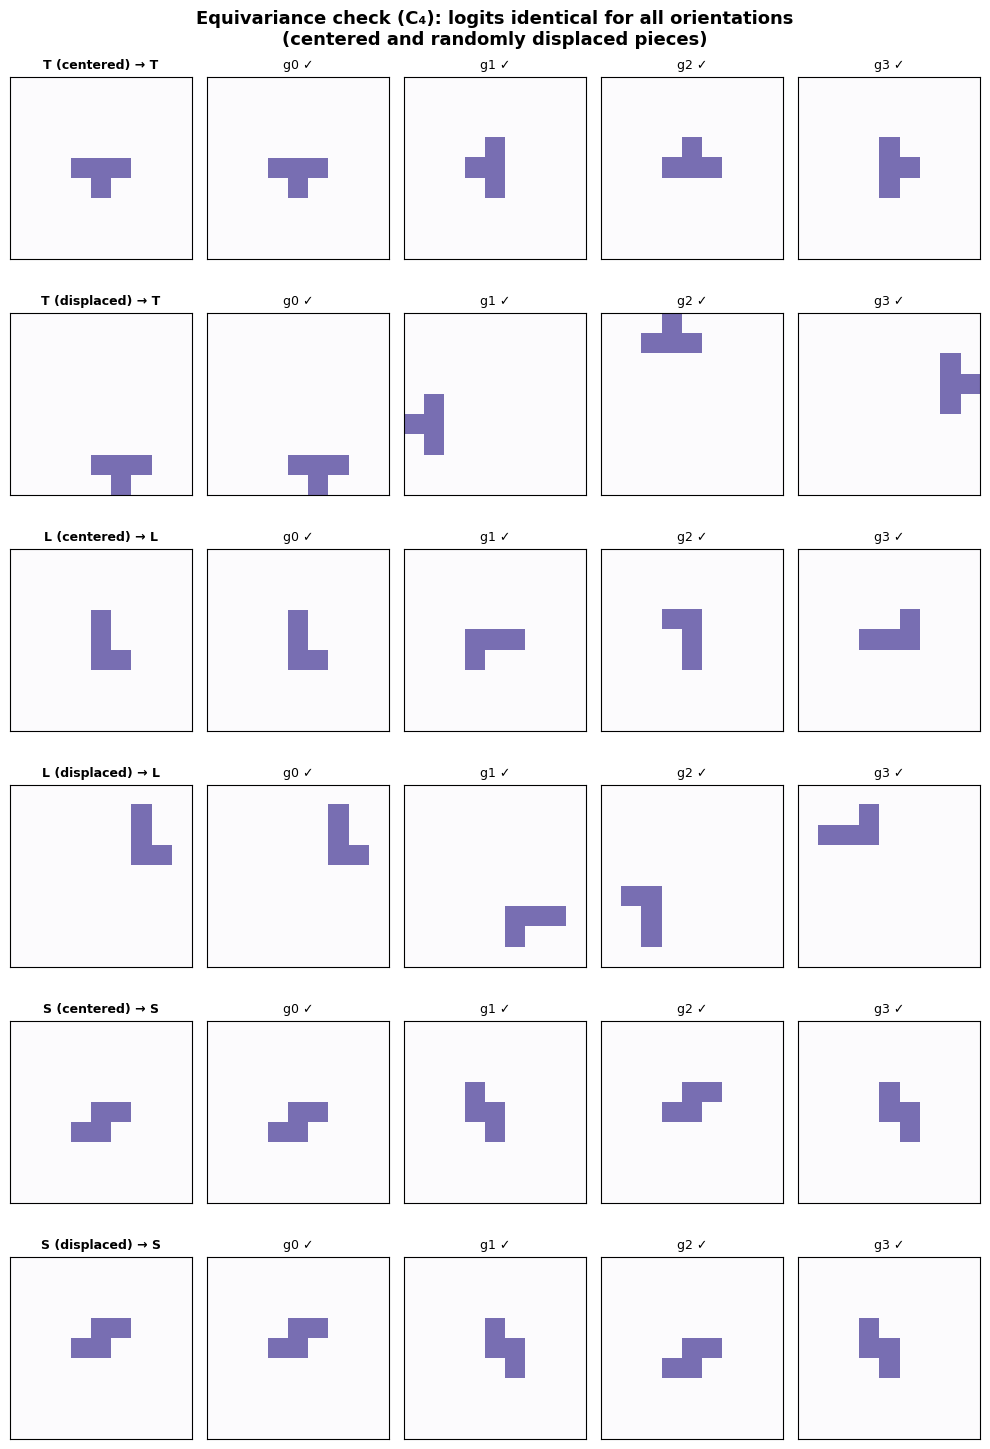

In [17]:
def verify_equivariance(model, group_matrices, group_name, class_names, grid_size=9):
    """Show the model gives identical logits for all orientations, including at random positions."""
    model.eval()
    perm_rep_full = image2D_permutation_representation(
        torch.tensor(group_matrices, dtype=torch.float32), [grid_size, grid_size]
    )
    test_pieces = ['T', 'L', 'S']
    n_g = len(group_matrices)

    # Two rows per piece: centered, then randomly displaced
    np.random.seed(7)
    fig, axes = plt.subplots(len(test_pieces) * 2, n_g + 1,
                             figsize=(2*(n_g+1), 2.5*len(test_pieces)*2))
    for row_block, name in enumerate(test_pieces):
        coords = PIECES[name]
        for sub_row, desc in enumerate(['centered', 'displaced']):
            row = row_block * 2 + sub_row
            if desc == 'centered':
                img = place_piece(coords, grid_size, translation=(CENTER, CENTER))
            else:
                # Random position
                rotated = apply_group_element_2D(coords, group_matrices[0])
                img = place_piece(rotated, grid_size)  # random translation

            img_t = torch.tensor(img, dtype=torch.float32).reshape(1, 1, grid_size, grid_size)
            with torch.no_grad():
                logits_orig = model(img_t)
                pred = class_names[logits_orig.argmax(1).item()]

            ax = axes[row, 0]
            ax.imshow(img, cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
            ax.set_title(f'{name} ({desc}) → {pred}', fontsize=9, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])

            for g_idx in range(n_g):
                rot_flat = perm_rep_full[g_idx] @ torch.tensor(img.flatten(), dtype=torch.float32)
                rot_img = rot_flat.reshape(grid_size, grid_size)
                with torch.no_grad():
                    logits_rot = model(rot_img.reshape(1, 1, grid_size, grid_size))
                    max_diff = (logits_rot - logits_orig).abs().max().item()
                ax = axes[row, g_idx + 1]
                ax.imshow(rot_img.numpy(), cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
                mark = '✓' if max_diff < 1e-4 else f'Δ={max_diff:.1e}'
                ax.set_title(f'g{g_idx} {mark}', fontsize=9)
                ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'Equivariance check ({group_name}): logits identical for all orientations\n'
                 f'(centered and randomly displaced pieces)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

verify_equivariance(c4_model, C4, 'C₄', C4_CLASS_NAMES)

---
## Train $D_4$ model: 5 images → 100% on all rotations, reflections, and positions

Under $D_4$, L$\leftrightarrow$J and S$\leftrightarrow$Z are equivalent → **5 classes**, so **5 training images**.

In [18]:
d4_train_imgs, d4_train_labels, d4_train_names = make_training_set(D4_CLASSES)

np.random.seed(42)
d4_test_imgs, d4_test_labels = make_test_set(D4_CLASSES, D4, n_per_piece=100)

print(f"Training: {len(d4_train_labels)} images — {d4_train_names}")
print(f"Test:     {len(d4_test_labels)} images (random D4 transforms + positions)")

Training: 5 images — ['I', 'O', 'T', 'S', 'L']
Test:     700 images (random D4 transforms + positions)


Epoch 100: loss=1.2634  train_acc=1.000  test_acc=1.000
Epoch 200: loss=0.4851  train_acc=1.000  test_acc=1.000


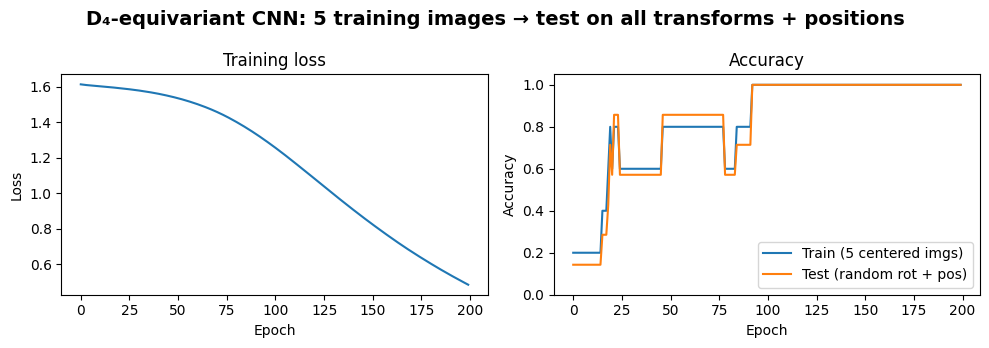

In [19]:
torch.manual_seed(0)
d4_model = GroupEquivariantCNN(group='D4', num_classes=5)
d4_history = train_model(d4_model, d4_train_imgs, d4_train_labels,
                         d4_test_imgs, d4_test_labels, epochs=200)
plot_history(d4_history, 'D₄-equivariant CNN: 5 training images → test on all transforms + positions',
             n_train=len(d4_train_labels))

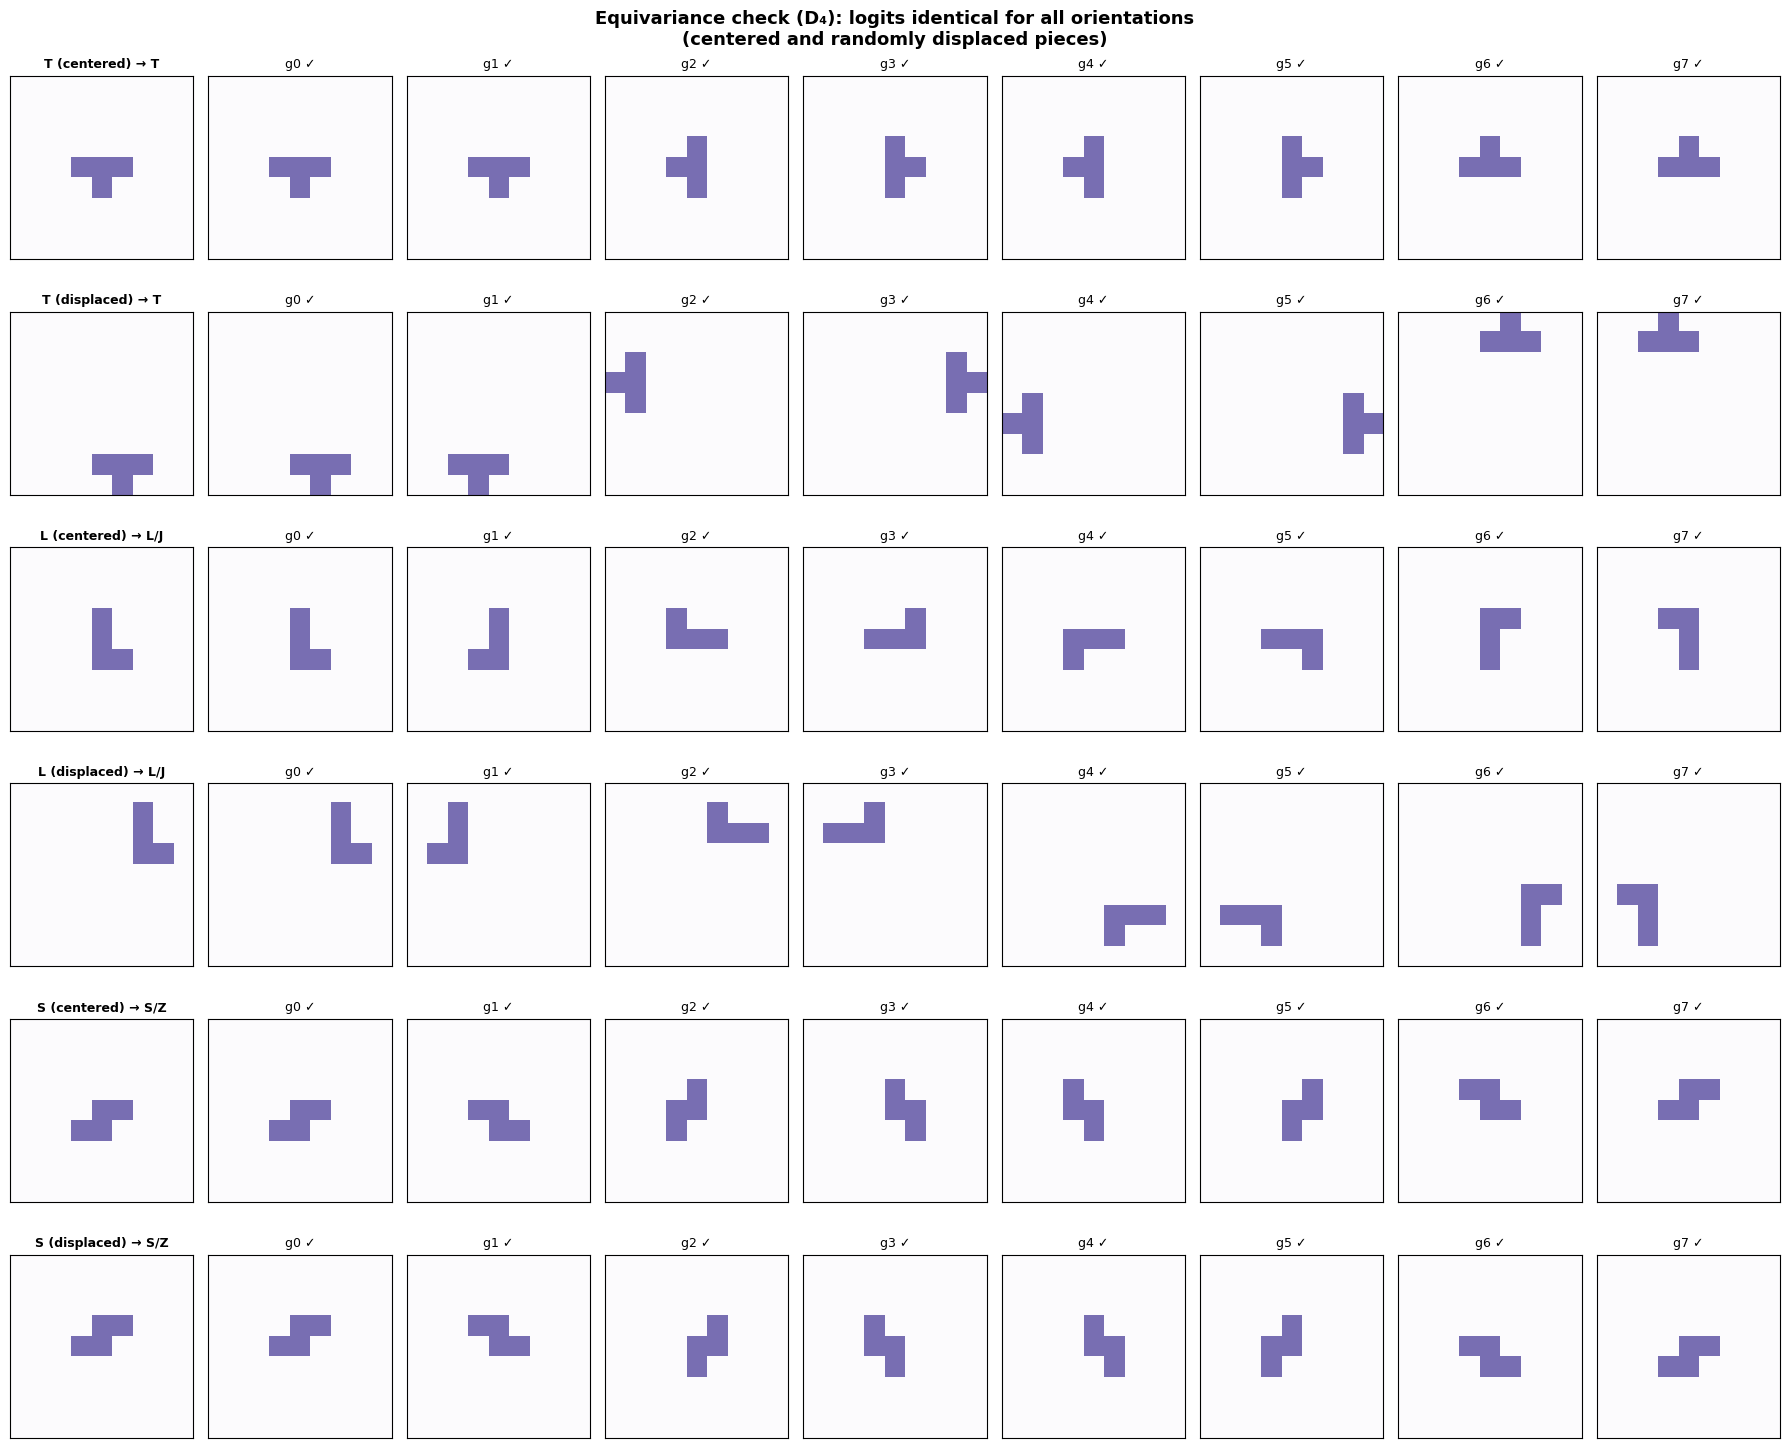

In [21]:
verify_equivariance(d4_model, D4, 'D₄', D4_CLASS_NAMES)

---
## Distinguishing L from J with the $A_2$ pseudoscalar

The $D_4$ model with $A_1$ (mean) pooling over the group treats L and J as identical — they're in the same orbit under reflections.

But what if we want to tell L from J? We need a **pseudoscalar**: a quantity that is invariant under rotations but **flips sign** under reflections.

The $A_2$ irrep of $D_4$ is exactly this:
$$\chi_{A_2}(g) = \det(g) = \begin{cases} +1 & \text{rotations} \\ -1 & \text{reflections} \end{cases}$$

If we pool over the group using $A_2$ characters instead of averaging ($A_1$):
$$f_{A_2} = \frac{1}{|G|} \sum_g \chi_{A_2}(g) \, f(g) = \frac{1}{|G|} \sum_g \det(g) \, f(g)$$

then for a reflected input $\sigma \cdot x$:
$$f_{A_2}(\sigma \cdot x) = -f_{A_2}(x)$$

So if we train the model on L → $+1$, it will **automatically** output $-1$ for J — without ever seeing J during training!

In [22]:
# A₂ characters for D4: det(g) for each group element
A2_chars = torch.tensor([np.linalg.det(g) for g in D4], dtype=torch.float32)
print("D4 elements and A₂ characters:")
for i, (g, chi) in enumerate(zip(D4, A2_chars)):
    kind = 'rotation' if chi > 0 else 'reflection'
    print(f"  g{i}: det={chi:+.0f} ({kind})")

D4 elements and A₂ characters:
  g0: det=+1 (rotation)
  g1: det=-1 (reflection)
  g2: det=-1 (reflection)
  g3: det=+1 (rotation)
  g4: det=+1 (rotation)
  g5: det=-1 (reflection)
  g6: det=-1 (reflection)
  g7: det=+1 (rotation)


In [23]:
class PseudoscalarCNN(torch.nn.Module):
    """D4-equivariant CNN with A₂ (pseudoscalar) pooling.
    
    Same architecture as GroupEquivariantCNN, but pools over the group
    using A₂ characters instead of averaging (A₁). The output flips
    sign under reflections.
    
    Two output channels: one for L/J detection, one for S/Z detection.
    No bias in the final linear layer — bias would break the sign-flip property.
    """
    def __init__(self, c1=16, c2=32):
        super().__init__()
        self.register_buffer('perm_rep', D4_perm_rep_3x3)
        self.register_buffer('reg_rep', D4_reg_rep)
        self.register_buffer('a2_chars', A2_chars)
        self.group_order = 8
        
        self.lift_w = torch.nn.Parameter(torch.randn(c1, 1, 3, 3) * 0.3)
        self.conv_w = torch.nn.Parameter(torch.randn(c2, c1, 8, 3, 3) * 0.1)
        self.fc = torch.nn.Linear(c2, 2, bias=False)
    
    def forward(self, x):
        x = lifting_convolution(self.perm_rep, x, self.lift_w)
        x = torch.relu(x)
        x = image2D_group_convolution(self.perm_rep, self.reg_rep, x, self.conv_w)
        x = torch.relu(x)
        x = x.mean(dim=(-2, -1))    # pool spatial -> [batch, c2, |G|]
        # A₂ projection (pseudoscalar pooling) instead of mean (A₁)
        x = (x * self.a2_chars.reshape(1, 1, -1)).sum(dim=-1) / self.group_order
        return self.fc(x)           # [batch, 2]

In [24]:
# Training data: just 2 centered images — L and S
# Channel 0: L → +1   (J will automatically give -1)
# Channel 1: S → +1   (Z will automatically give -1)

a2_train_imgs = torch.tensor(np.array([
    place_piece(PIECES['L'], GRID_SIZE, translation=(CENTER, CENTER)),
    place_piece(PIECES['S'], GRID_SIZE, translation=(CENTER, CENTER)),
]), dtype=torch.float32).unsqueeze(1)
a2_train_targets = torch.tensor([[1.0, 0.0], [0.0, 1.0]])

print("Training set: 2 images")
print("  L → [+1, 0]")
print("  S → [ 0,+1]")

Training set: 2 images
  L → [+1, 0]
  S → [ 0,+1]


In [25]:
# Train with MSE loss
torch.manual_seed(0)
a2_model = PseudoscalarCNN()
optimizer = torch.optim.Adam(a2_model.parameters(), lr=1e-3)

for epoch in range(500):
    a2_model.train()
    pred = a2_model(a2_train_imgs)
    loss = F.mse_loss(pred, a2_train_targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d}: MSE = {loss.item():.6f}")

Epoch 100: MSE = 0.308063
Epoch 200: MSE = 0.064871
Epoch 300: MSE = 0.000063
Epoch 400: MSE = 0.000000
Epoch 500: MSE = 0.000000


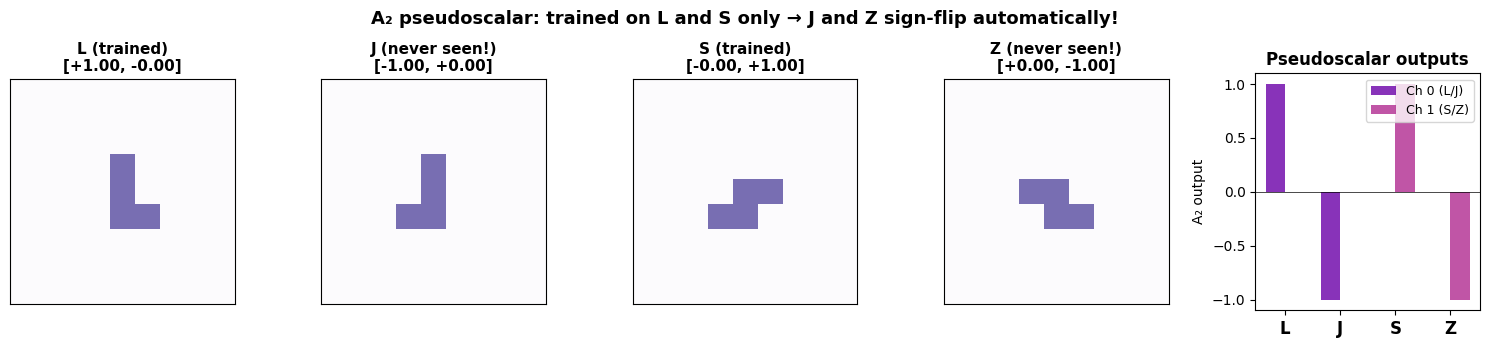

Results:
  L → [+1.0000, -0.0000]  (trained)
  J → [-1.0000, +0.0000]  (NEVER SEEN — sign flipped!)
  S → [-0.0000, +1.0000]  (trained)
  Z → [+0.0000, -1.0000]  (NEVER SEEN — sign flipped!)

Sign-flip check: L+J = [0.000000, -0.000000]
                 S+Z = [0.000000, 0.000000]


In [26]:
# Test: the model has NEVER seen J or Z!
a2_model.eval()

test_pieces = ['L', 'J', 'S', 'Z']
test_imgs_list = [place_piece(PIECES[name], GRID_SIZE, translation=(CENTER, CENTER))
                  for name in test_pieces]
test_tensors = torch.tensor(np.array(test_imgs_list), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    outputs = a2_model(test_tensors)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for i, name in enumerate(test_pieces):
    axes[i].imshow(test_imgs_list[i], cmap='Purples', vmin=0, vmax=1.5, interpolation='nearest')
    out = outputs[i].numpy()
    trained = '(trained)' if name in ['L', 'S'] else '(never seen!)'
    axes[i].set_title(f'{name} {trained}\n[{out[0]:+.2f}, {out[1]:+.2f}]',
                      fontsize=11, fontweight='bold')
    axes[i].set_xticks([]); axes[i].set_yticks([])

# Bar chart
ax = axes[4]
x_pos = np.arange(4)
width = 0.35
ax.bar(x_pos - width/2, outputs[:, 0].numpy(), width, label='Ch 0 (L/J)', color='#6a00a8', alpha=0.8)
ax.bar(x_pos + width/2, outputs[:, 1].numpy(), width, label='Ch 1 (S/Z)', color='#b12a90', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(test_pieces, fontsize=12, fontweight='bold')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.set_ylabel('A₂ output'); ax.legend(fontsize=9)
ax.set_title('Pseudoscalar outputs', fontsize=12, fontweight='bold')

fig.suptitle('A₂ pseudoscalar: trained on L and S only → J and Z sign-flip automatically!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Results:")
for name, out in zip(test_pieces, outputs):
    trained = '(trained)' if name in ['L', 'S'] else '(NEVER SEEN — sign flipped!)'
    print(f"  {name} → [{out[0]:+.4f}, {out[1]:+.4f}]  {trained}")
print(f"\nSign-flip check: L+J = [{outputs[0,0]+outputs[1,0]:.6f}, {outputs[0,1]+outputs[1,1]:.6f}]")
print(f"                 S+Z = [{outputs[2,0]+outputs[3,0]:.6f}, {outputs[2,1]+outputs[3,1]:.6f}]")

The $A_2$ output for J is the **exact negative** of L, and Z is the exact negative of S. This sign flip is guaranteed by the equivariant architecture — the network has **never seen** J or Z during training.

This is how chirality works in physics: a pseudoscalar distinguishes left from right. The $A_2$ irrep is the "handedness detector" of $D_4$.

---
## Summary

| | $A_1$ (invariant) pool | $A_2$ (pseudoscalar) pool |
|---|---|---|
| **Irrep** | Trivial: $\chi(g) = 1$ for all $g$ | $\chi(g) = \det(g)$: $+1$ rotations, $-1$ reflections |
| **L vs J** | Same output | Opposite sign |
| **S vs Z** | Same output | Opposite sign |
| **Use case** | Classification ignoring chirality | Detecting handedness |

**Key takeaways:**
1. Group equivariant CNNs generalize to all orientations and positions from a **single centered training image per class** — no augmentation needed.
2. Averaging over the group ($A_1$ pooling) gives **invariant** outputs — rotated and reflected inputs produce identical predictions.
3. The $A_2$ irrep gives a **pseudoscalar** output that flips sign under reflections — distinguishing chiral pairs like L/J and S/Z.
4. The choice of how to pool over the group dimension (which irrep to project onto) determines what information survives.